# Project Context - Goal - Method

In The financial sector, Survey's are regularly conducted to see whether market participants feel this is a :
- *Risk on* period : they are more willing to take on risk for higher returns in equities, emerging markets and speculative investments.
- *Risk off* Period : They are less willing to take on risk and thus invest in safe haven assets like bonds of certain countries like the US, Germany or switzerland, gold etc...

We have a Semi-supervised task, where we are trying to perform anomaly detection or more precisely Novelty detection on whether current conditions imply a risk on or risk off period using a rich panel dataset of  financial data with a labeling of Risk-on/off for the particular day based on the surveys, this will be used for evaluation and benchmarking.

Inherently, the idea of our approach is that **Markets are Forward Looking**, Believing in some form of Efficient Market Hypothesis, The prices of financial assets incorporate information about future expectations on these assets by investors, we will allude to this fact many times during our project. Believing also in some form of Boom-Bust reflexive relationship - the kind famously described by George Soros - between assets and expectations. we aim to provide an novelty detection using this framework.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configure visualization settings
sns.set_theme(style="whitegrid")
sns.set_context("notebook", font_scale=1.5)


In [ ]:
file_path = './Dataset4_EWS.xlsx'

plt.rcParams['figure.figsize'] = [10, 6]

# load the data 
data_df = pd.read_excel(file_path, sheet_name='Markets')
metadata_df = pd.read_excel(file_path, sheet_name='Metadata')

# Structure of the loaded data
print("Data columns:", data_df.columns.tolist())

# Extract date and anomaly label columns
date_col = 'Date' if 'Date' in data_df.columns else data_df.columns[0]
y_col = 'Y' if 'Y' in data_df.columns else None

# Convert dates to datetime format
data_df[date_col] = pd.to_datetime(data_df[date_col], dayfirst=True)  # Date format is dd/mm/yy
data_df = data_df.set_index(date_col)

# Extract features 
if y_col:
    X_df = data_df.drop(y_col, axis=1)
    y = data_df[y_col].values
else:
    X_df = data_df
    y = None

# Display dataset info
print(f"Data shape: {X_df.shape}")
print(f"Total number of records: {len(X_df)}")
print(f"Time period: from {X_df.index.min().strftime('%m/%d/%Y')} to {X_df.index.max().strftime('%m/%d/%Y')}")
print(f"Frequency: {pd.infer_freq(X_df.index) or 'Weekly'}")
print(f"Number of variables: {X_df.shape[1]}")
if y_col:
    print(f"Number of anomalies: {np.sum(y == 1)} ({np.mean(y == 1)*100:.2f}%)")


enhanced_metadata = []
ticker_col = 'ticker' if 'ticker' in metadata_df.columns else metadata_df.columns[0]
desc_col = 'description' if 'description' in metadata_df.columns else metadata_df.columns[1] if len(metadata_df.columns) > 1 else ticker_col

for ticker in X_df.columns:
    meta_row = metadata_df[metadata_df[ticker_col] == ticker] if ticker in metadata_df[ticker_col].values else pd.DataFrame()

    # Get description or use ticker if not found
    description = meta_row[desc_col].values[0] if not meta_row.empty and desc_col in meta_row.columns else ticker

    # Calculate statistics for this series
    series = X_df[ticker]

    enhanced_metadata.append({
        'Ticker': ticker,
        'Description': description,
        'Mean': series.mean(),
        'Std.Dev': series.std(),
        'Min': series.min(),
        'Max': series.max(),
        'Missing values': series.isna().sum(),
        'Missing (%)': f"{series.isna().mean()*100:.2f}%"
    })

# Create enhanced metadata dataframe
enhanced_meta_df = pd.DataFrame(enhanced_metadata)

# Display the enhanced metadata
print("\nMetadata and statistics:")
display(enhanced_meta_df)


Data columns: ['Data', 'BDIY', 'CRY', 'Cl1', 'DXY', 'ECSURPUS', 'EMUSTRUU', 'EONIA', 'GBP', 'GT10', 'GTDEM10Y', 'GTDEM2Y', 'GTDEM30Y', 'GTGBP20Y', 'GTGBP2Y', 'GTGBP30Y', 'GTITL10YR', 'GTITL2YR', 'GTITL30YR', 'GTJPY10YR', 'GTJPY2YR', 'GTJPY30YR', 'JPY', 'LF94TRUU', 'LF98TRUU', 'LG30TRUU', 'LMBITR', 'LP01TREU', 'LUACTRUU', 'LUMSTRUU', 'MXBR', 'MXCN', 'MXEU', 'MXIN', 'MXJP', 'MXRU', 'MXUS', 'US0001M', 'USGG2YR', 'USGG30YR', 'USGG3M', 'VIX', 'XAUBGNL', 'Y']
Data shape: (1111, 42)
Total number of records: 1111
Time period: from 01/11/2000 to 04/20/2021
Frequency: W-TUE
Number of variables: 42
Number of anomalies: 237 (21.33%)

Metadata and statistics:


,Ticker,Description,Mean,Std.Dev,Min,Max,Missing values,Missing (%)
0,BDIY,Baltic Dry Index,2259.860486,2017.811888,291.00000,11793.00000,0,0.00%
1,CRY,TR/CC CRB ER Index,245.247649,68.278081,106.29290,467.57000,0,0.00%
2,Cl1,Generic 1st 'CL' Future,60.708101,25.900813,10.01000,140.97000,0,0.00%
3,DXY,DOLLAR INDEX SPOT,90.934982,11.379095,71.32900,119.82000,0,0.00%
4,ECSURPUS,Bloomberg ECO US Surprise Inde,0.036153,0.349453,-0.97400,0.99100,0,0.00%
5,EMUSTRUU,EM USD Aggregate,704.379495,309.951768,230.52670,1286.35300,0,0.00%
6,EONIA,EMMI EURO OverNight Index Aver,1.363676,1.721894,-0.49800,5.73000,0,0.00%
7,GBP,British Pound Spot,1.569618,0.212340,1.17230,2.08520,0,0.00%
8,GT10,US TREASURY N/B,3.266748,1.332464,0.50800,6.74800,0,0.00%
9,GTDEM10Y,BUNDESREPUB. DEUTSCHLAND,2.448365,1.851558,-0.79400,5.64400,0,0.00%


In [8]:
def Plot_riskperiod_asset(x):
    if y_col and x in X_df.columns:
        fig, ax = plt.subplots(figsize=(14, 8))
        ax.plot(X_df.index, X_df[x], color='darkred', linewidth=2.5, label=x)
        y_min, y_max = ax.get_ylim()
        for i, (date, is_anomaly) in enumerate(zip(X_df.index, y)):
            if is_anomaly == 1:
                ax.axvspan(date, date + pd.Timedelta(days=7), alpha=0.3, color='navy', label='Risk-on/Risk-off' if i == 0 else "")
        ax.set_xlabel('Timeline')
        ax.set_ylabel(x)
        ax.set_title(x + ' and risk-on/risk-off periods')

        # Add legend
        handles, labels = ax.get_legend_handles_labels()
        by_label = dict(zip(labels, handles))
        ax.legend(by_label.values(), by_label.keys(), loc='best')

        plt.tight_layout()
        plt.show()
    else:
        print("Either 'Y' column or input column is missing in the dataset.")

## Emerging Markets
We would assume that Emerging markets are very sensitive and positively correlated to risk off periods, i.e they tend to have negative returns, in these periods as investors reduce their exposures.

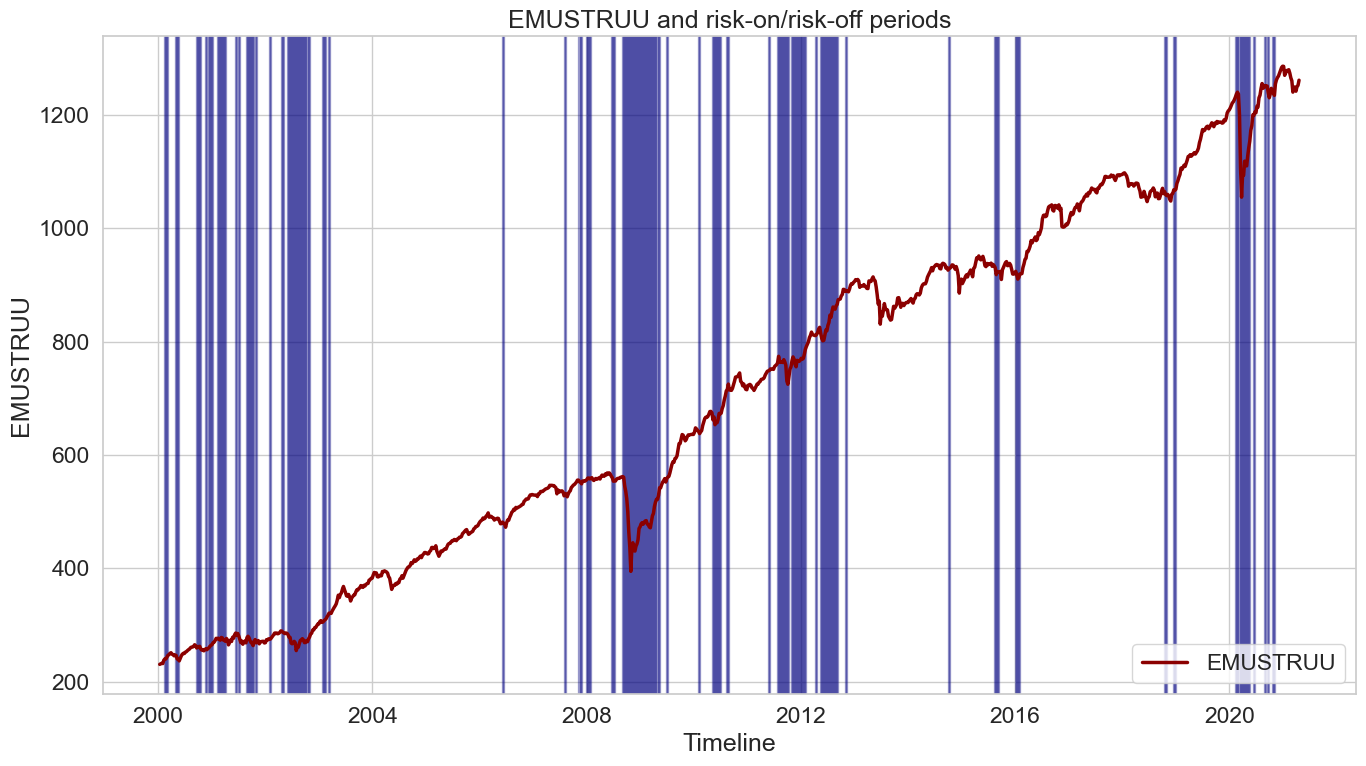

In [11]:
asset = 'EMUSTRUU'
Plot_riskperiod_asset(asset)

## The Greenback
We would assume that Dollars is very sensitive and inversely correlated to risk off periods, i.e the dollar tends to have appreciate, in these periods as investors increase their exposures to safe haven assets like US government bonds.

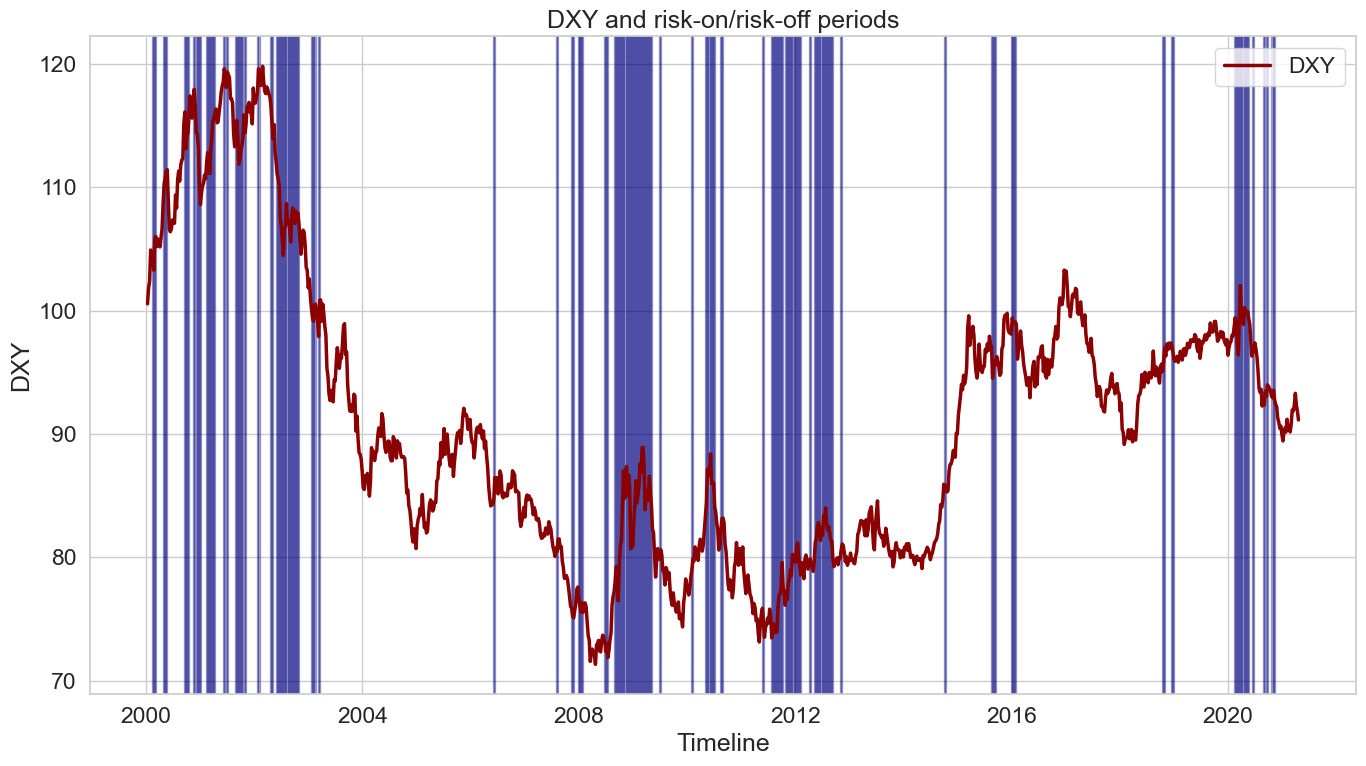

In [12]:
asset = 'DXY'
Plot_riskperiod_asset(asset)

In [15]:
data_df.head()

,BDIY,CRY,Cl1,DXY,ECSURPUS,EMUSTRUU,EONIA,GBP,GT10,GTDEM10Y,...,MXJP,MXRU,MXUS,US0001M,USGG2YR,USGG30YR,USGG3M,VIX,XAUBGNL,Y
Data,,,,,,,,,,,,,,,,,,,,,
2000-01-11,1388,157.26,25.77,100.56,0.077,230.5267,2.89,1.6460,6.657,5.541,...,990.59,224.33,1416.12,5.78125,6.428,6.671,5.426,22.50,283.25,0
2000-01-18,1405,165.01,28.85,101.86,0.043,231.3770,3.03,1.6383,6.748,5.644,...,993.98,234.37,1428.79,5.80250,6.465,6.747,5.378,21.50,287.65,0
2000-01-25,1368,167.24,28.28,102.41,0.135,232.3895,3.15,1.6496,6.692,5.515,...,974.83,216.82,1385.93,5.81875,6.432,6.634,5.562,23.02,287.15,0
2000-02-01,1311,166.85,28.22,104.92,0.191,231.9417,3.30,1.6106,6.619,5.459,...,1007.12,201.89,1385.31,5.88500,6.574,6.423,5.708,23.45,282.75,0
2000-02-08,1277,165.43,28.02,104.22,0.312,237.8117,3.26,1.6108,6.613,5.482,...,1034.58,218.00,1411.95,5.89125,6.678,6.231,5.677,21.25,298.40,1


In [17]:
correlations = data_df.corr()['Y'].sort_values()

print("Correlation with Risk-Off Regime (1):")
correlations

Correlation with Risk-Off Regime (1):


MXJP        -0.279399
MXEU        -0.253877
LP01TREU    -0.209774
LG30TRUU    -0.197232
MXUS        -0.193928
LF98TRUU    -0.189661
MXIN        -0.188942
EMUSTRUU    -0.169475
LF94TRUU    -0.156550
LUACTRUU    -0.153544
JPY         -0.151197
MXCN        -0.149581
MXRU        -0.148848
LMBITR      -0.143607
LUMSTRUU    -0.104897
GBP         -0.093167
ECSURPUS    -0.090772
BDIY        -0.083440
CRY         -0.074102
Cl1         -0.070141
MXBR        -0.043429
USGG2YR     -0.034909
USGG3M      -0.025927
XAUBGNL     -0.011535
GT10        -0.004776
US0001M      0.015375
USGG30YR     0.019260
GTGBP2Y      0.035003
GTGBP30Y     0.099777
GTGBP20Y     0.100130
DXY          0.103227
GTJPY2YR     0.112314
GTJPY30YR    0.114555
GTDEM2Y      0.130607
GTJPY10YR    0.133660
GTDEM10Y     0.139933
GTDEM30Y     0.141537
EONIA        0.180311
GTITL30YR    0.295000
GTITL10YR    0.297573
GTITL2YR     0.304528
VIX          0.598432
Y            1.000000
Name: Y, dtype: float64